In [ ]:
# ==========================================================
# PART 1
# IMPORT DEPTH + TRADES FILES
# ACD-TRANSFORMER V2
# ==========================================================

import pandas as pd
import numpy as np

from google.colab import files

# ----------------------------------------------------------
# UPLOAD FILES
# ----------------------------------------------------------

uploaded = files.upload()

print("=" * 70)
print("FILES UPLOADED")
print("=" * 70)

print(list(uploaded.keys()))

# ----------------------------------------------------------
# AUTOMATICALLY IDENTIFY FILES
# ----------------------------------------------------------

depth_file = None
trade_file = None

for file in uploaded.keys():

    if "Depth" in file or "depth" in file:
        depth_file = file

    elif "Trade" in file or "trade" in file:
        trade_file = file

# ----------------------------------------------------------
# CHECK FILES
# ----------------------------------------------------------

if depth_file is None:
    raise FileNotFoundError(
        "BTCUSDT Depth CSV was not uploaded."
    )

if trade_file is None:
    raise FileNotFoundError(
        "BTCUSDT Trades CSV was not uploaded."
    )

# ----------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------

depth = pd.read_csv(depth_file)

trades = pd.read_csv(trade_file)

# ----------------------------------------------------------
# BASIC INFORMATION
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("DEPTH DATA")
print("=" * 70)

print("File :", depth_file)
print("Shape:", depth.shape)

print("\n" + "=" * 70)
print("TRADES DATA")
print("=" * 70)

print("File :", trade_file)
print("Shape:", trades.shape)

# ----------------------------------------------------------
# DISPLAY COLUMN NAMES
# ----------------------------------------------------------

print("\n" + "=" * 70)
print("DEPTH COLUMNS")
print("=" * 70)

for i, col in enumerate(depth.columns):
    print(i, "-", col)

print("\n" + "=" * 70)
print("TRADE COLUMNS")
print("=" * 70)

for i, col in enumerate(trades.columns):
    print(i, "-", col)

Saving BTCUSDT_Depth_1Hour.csv to BTCUSDT_Depth_1Hour (1).csv
Saving BTCUSDT_Trades_1Hour.csv to BTCUSDT_Trades_1Hour.csv
FILES UPLOADED
['BTCUSDT_Depth_1Hour (1).csv', 'BTCUSDT_Trades_1Hour.csv']

DEPTH DATA
File : BTCUSDT_Depth_1Hour (1).csv
Shape: (35901, 45)

TRADES DATA
File : BTCUSDT_Trades_1Hour.csv
Shape: (66803, 5)

DEPTH COLUMNS
0 - timestamp
1 - best_bid
2 - best_bid_qty
3 - best_ask
4 - best_ask_qty
5 - bid_price_1
6 - bid_qty_1
7 - ask_price_1
8 - ask_qty_1
9 - bid_price_2
10 - bid_qty_2
11 - ask_price_2
12 - ask_qty_2
13 - bid_price_3
14 - bid_qty_3
15 - ask_price_3
16 - ask_qty_3
17 - bid_price_4
18 - bid_qty_4
19 - ask_price_4
20 - ask_qty_4
21 - bid_price_5
22 - bid_qty_5
23 - ask_price_5
24 - ask_qty_5
25 - bid_price_6
26 - bid_qty_6
27 - ask_price_6
28 - ask_qty_6
29 - bid_price_7
30 - bid_qty_7
31 - ask_price_7
32 - ask_qty_7
33 - bid_price_8
34 - bid_qty_8
35 - ask_price_8
36 - ask_qty_8
37 - bid_price_9
38 - bid_qty_9
39 - ask_price_9
40 - ask_qty_9
41 - bid_price

In [ ]:
# ==========================================================
# PART 2
# DEPTH + TRADES PREPROCESSING
# ACD-TRANSFORMER V2
# ==========================================================

# ----------------------------------------------------------
# 1. COPY DATA
# ----------------------------------------------------------

depth_df = depth.copy()
trades_df = trades.copy()

# ----------------------------------------------------------
# 2. TIMESTAMP CONVERSION
# ----------------------------------------------------------

depth_df["timestamp"] = pd.to_datetime(
    depth_df["timestamp"],
    errors="coerce"
)

trades_df["timestamp"] = pd.to_datetime(
    trades_df["timestamp"],
    errors="coerce"
)

# ----------------------------------------------------------
# 3. REMOVE INVALID TIMESTAMPS
# ----------------------------------------------------------

depth_df = depth_df.dropna(
    subset=["timestamp"]
).copy()

trades_df = trades_df.dropna(
    subset=["timestamp"]
).copy()

# ----------------------------------------------------------
# 4. SORT CHRONOLOGICALLY
# ----------------------------------------------------------

depth_df = depth_df.sort_values(
    "timestamp"
).reset_index(drop=True)

trades_df = trades_df.sort_values(
    "timestamp"
).reset_index(drop=True)

# ----------------------------------------------------------
# 5. REMOVE DUPLICATES
# ----------------------------------------------------------

depth_df = depth_df.drop_duplicates(
    subset=["timestamp"]
).reset_index(drop=True)

trades_df = trades_df.drop_duplicates(
    subset=["trade_id"]
).reset_index(drop=True)

# ----------------------------------------------------------
# 6. NUMERIC CONVERSION
# ----------------------------------------------------------

depth_numeric = [
    col for col in depth_df.columns
    if col != "timestamp"
]

trades_numeric = [
    "price",
    "quantity",
    "buyer_maker"
]

for col in depth_numeric:

    depth_df[col] = pd.to_numeric(
        depth_df[col],
        errors="coerce"
    )

for col in trades_numeric:

    trades_df[col] = pd.to_numeric(
        trades_df[col],
        errors="coerce"
    )

# ----------------------------------------------------------
# 7. BASIC CLEANING
# ----------------------------------------------------------

depth_df = depth_df.dropna(
    subset=[
        "best_bid",
        "best_bid_qty",
        "best_ask",
        "best_ask_qty"
    ]
).reset_index(drop=True)

trades_df = trades_df.dropna(
    subset=[
        "price",
        "quantity"
    ]
).reset_index(drop=True)

# ----------------------------------------------------------
# 8. VALIDATE DEPTH
# ----------------------------------------------------------

depth_df["Valid_Book"] = (

    (depth_df["best_bid"] > 0) &

    (depth_df["best_ask"] > 0) &

    (depth_df["best_bid"] < depth_df["best_ask"]) &

    (depth_df["best_bid_qty"] >= 0) &

    (depth_df["best_ask_qty"] >= 0)

)

invalid_depth = (
    ~depth_df["Valid_Book"]
).sum()

depth_df = depth_df[
    depth_df["Valid_Book"]
].copy()

depth_df.reset_index(
    drop=True,
    inplace=True
)

# ----------------------------------------------------------
# 9. TRADE VALIDATION
# ----------------------------------------------------------

valid_trades = (

    (trades_df["price"] > 0) &

    (trades_df["quantity"] > 0)

)

invalid_trades = (
    ~valid_trades
).sum()

trades_df = trades_df[
    valid_trades
].copy()

trades_df.reset_index(
    drop=True,
    inplace=True
)

# ----------------------------------------------------------
# 10. DATASET REPORT
# ----------------------------------------------------------

print("=" * 70)
print("DEPTH + TRADES PREPROCESSING")
print("=" * 70)

print()

print("DEPTH")
print("Initial rows :", len(depth))
print("Final rows   :", len(depth_df))
print("Invalid LOB  :", invalid_depth)

print()

print("TRADES")
print("Initial rows :", len(trades))
print("Final rows   :", len(trades_df))
print("Invalid trades:", invalid_trades)

print()

print("=" * 70)
print("TIME RANGE")
print("=" * 70)

print(
    "Depth start :",
    depth_df["timestamp"].min()
)

print(
    "Depth end   :",
    depth_df["timestamp"].max()
)

print()

print(
    "Trades start:",
    trades_df["timestamp"].min()
)

print(
    "Trades end  :",
    trades_df["timestamp"].max()
)

print()

print("=" * 70)
print("TRADE SIDE INFORMATION")
print("=" * 70)

print(
    trades_df["buyer_maker"]
    .value_counts(dropna=False)
)

print()

print("=" * 70)
print("TRADE SUMMARY")
print("=" * 70)

print(
    trades_df[
        ["price", "quantity"]
    ].describe()
)

DEPTH + TRADES PREPROCESSING

DEPTH
Initial rows : 35901
Final rows   : 31354
Invalid LOB  : 2289

TRADES
Initial rows : 66803
Final rows   : 66803
Invalid trades: 0

TIME RANGE
Depth start : 2024-03-01 00:00:00.289000
Depth end   : 2024-03-01 00:59:59.966000

Trades start: 2024-02-29 23:59:59.998000
Trades end  : 2024-03-01 00:59:59.995000

TRADE SIDE INFORMATION
buyer_maker
True     35616
False    31187
Name: count, dtype: int64

TRADE SUMMARY
              price      quantity
count  66803.000000  66803.000000
mean   61475.359315      0.027960
std      167.848146      0.099907
min    61126.000000      0.000010
25%    61324.580000      0.000260
50%    61504.800000      0.002010
75%    61610.000000      0.012440
max    61749.000000      8.312980


In [ ]:
# ==========================================================
# PART 3
# TRADE–LOB TIMESTAMP ALIGNMENT
# ACD-TRANSFORMER V2
# ==========================================================

# ----------------------------------------------------------
# 1. KEEP REQUIRED TRADE INFORMATION
# ----------------------------------------------------------

trade_events = trades_df[
    [
        "timestamp",
        "price",
        "quantity",
        "buyer_maker",
        "trade_id"
    ]
].copy()

trade_events = trade_events.sort_values(
    "timestamp"
).reset_index(drop=True)

depth_events = depth_df.copy()

depth_events = depth_events.sort_values(
    "timestamp"
).reset_index(drop=True)

# ----------------------------------------------------------
# 2. RENAME TRADE COLUMNS
# ----------------------------------------------------------

trade_events = trade_events.rename(
    columns={
        "timestamp": "trade_timestamp",
        "price": "trade_price",
        "quantity": "trade_quantity",
        "buyer_maker": "trade_buyer_maker",
        "trade_id": "matched_trade_id"
    }
)

# ----------------------------------------------------------
# 3. AS-OF MERGE
# ----------------------------------------------------------
#
# For every LOB snapshot, find the latest trade occurring
# at or before that snapshot.
#
# tolerance = 100 milliseconds
#
# This prevents an old trade from being incorrectly attached
# to a much later LOB snapshot.
# ----------------------------------------------------------

aligned = pd.merge_asof(

    depth_events.sort_values("timestamp"),

    trade_events.sort_values("trade_timestamp"),

    left_on="timestamp",

    right_on="trade_timestamp",

    direction="backward",

    tolerance=pd.Timedelta(
        milliseconds=100
    )

)

# ----------------------------------------------------------
# 4. TRADE PRESENCE
# ----------------------------------------------------------

aligned["Trade_Observed"] = (
    aligned["trade_timestamp"]
    .notna()
    .astype(int)
)

# ----------------------------------------------------------
# 5. TIME BETWEEN TRADE AND LOB SNAPSHOT
# ----------------------------------------------------------

aligned["Trade_Latency"] = (

    aligned["timestamp"]

    -

    aligned["trade_timestamp"]

).dt.total_seconds()

# ----------------------------------------------------------
# 6. TRADE SIDE
# ----------------------------------------------------------
#
# buyer_maker = True
#     → buyer was maker
#     → aggressive side was seller
#
# buyer_maker = False
#     → seller was maker
#     → aggressive side was buyer
#
# Therefore:
#
# +1 = buyer-initiated trade
# -1 = seller-initiated trade
# ----------------------------------------------------------

aligned["Trade_Side"] = np.nan

aligned.loc[
    aligned["trade_buyer_maker"] == False,
    "Trade_Side"
] = 1

aligned.loc[
    aligned["trade_buyer_maker"] == True,
    "Trade_Side"
] = -1

# ----------------------------------------------------------
# 7. SIGNED TRADE VOLUME
# ----------------------------------------------------------

aligned["Signed_Trade_Volume"] = (

    aligned["trade_quantity"]

    *

    aligned["Trade_Side"]

)

# ----------------------------------------------------------
# 8. TRADE VALUE
# ----------------------------------------------------------

aligned["Trade_Value"] = (

    aligned["trade_price"]

    *

    aligned["trade_quantity"]

)

# ----------------------------------------------------------
# 9. TRADE PRICE VS MIDPRICE
# ----------------------------------------------------------

aligned["MidPrice"] = (

    aligned["best_bid"]

    +

    aligned["best_ask"]

) / 2

aligned["Trade_Mid_Deviation"] = (

    aligned["trade_price"]

    -

    aligned["MidPrice"]

)

# ----------------------------------------------------------
# 10. TRADE VS BEST BID / ASK
# ----------------------------------------------------------

aligned["Trade_At_Bid"] = (

    np.isclose(

        aligned["trade_price"],

        aligned["best_bid"],

        rtol=0,

        atol=1e-8

    )

).astype(int)

aligned["Trade_At_Ask"] = (

    np.isclose(

        aligned["trade_price"],

        aligned["best_ask"],

        rtol=0,

        atol=1e-8

    )

).astype(int)

# ----------------------------------------------------------
# 11. TRADE CLASSIFICATION SIGNAL
# ----------------------------------------------------------

aligned["Aggressive_Buy"] = (

    (

        aligned["Trade_Observed"] == 1

    )

    &

    (

        aligned["Trade_Side"] == 1

    )

).astype(int)

aligned["Aggressive_Sell"] = (

    (

        aligned["Trade_Observed"] == 1

    )

    &

    (

        aligned["Trade_Side"] == -1

    )

).astype(int)

# ----------------------------------------------------------
# 12. TRADE INTENSITY
# ----------------------------------------------------------

aligned["Trade_Intensity"] = (

    aligned["trade_quantity"]

    /

    (

        aligned["Trade_Latency"]

        + 1e-6

    )

)

# ----------------------------------------------------------
# 13. REPORT
# ----------------------------------------------------------

print("=" * 70)
print("TRADE–LOB ALIGNMENT")
print("=" * 70)

print(
    "LOB snapshots:",
    len(aligned)
)

print(
    "Snapshots with trade:",
    aligned["Trade_Observed"].sum()
)

print(
    "Snapshots without trade:",
    (
        aligned["Trade_Observed"] == 0
    ).sum()
)

print()

print(
    "Trade-linked percentage:",
    round(
        aligned["Trade_Observed"].mean() * 100,
        2
    ),
    "%"
)

# ----------------------------------------------------------
# 14. TRADE SIDE DISTRIBUTION
# ----------------------------------------------------------

print()
print("=" * 70)
print("TRADE SIDE")
print("=" * 70)

print(
    aligned["Trade_Side"]
    .value_counts(dropna=False)
)

# ----------------------------------------------------------
# 15. TRADE SIZE SUMMARY
# ----------------------------------------------------------

print()
print("=" * 70)
print("TRADE SIZE")
print("=" * 70)

print(
    aligned[
        "trade_quantity"
    ].describe()
)

# ----------------------------------------------------------
# 16. SAMPLE
# ----------------------------------------------------------

print()
print("=" * 70)
print("ALIGNED DATA PREVIEW")
print("=" * 70)

print(

    aligned[
        [
            "timestamp",
            "best_bid",
            "best_ask",
            "trade_timestamp",
            "trade_price",
            "trade_quantity",
            "trade_buyer_maker",
            "Trade_Side",
            "Trade_Latency",
            "Trade_At_Bid",
            "Trade_At_Ask"
        ]
    ].head(15)

)

TRADE–LOB ALIGNMENT
LOB snapshots: 31354
Snapshots with trade: 12483
Snapshots without trade: 18871

Trade-linked percentage: 39.81 %

TRADE SIDE
Trade_Side
 NaN    18871
-1.0     6518
 1.0     5965
Name: count, dtype: int64

TRADE SIZE
count    12483.000000
mean         0.017451
std          0.050069
min          0.000010
25%          0.000410
50%          0.002000
75%          0.010460
max          0.928710
Name: trade_quantity, dtype: float64

ALIGNED DATA PREVIEW
                 timestamp  best_bid  best_ask         trade_timestamp  \
0  2024-03-01 00:00:00.289  61136.64  61136.65 2024-03-01 00:00:00.269   
1  2024-03-01 00:00:00.389  61136.64  61136.65 2024-03-01 00:00:00.388   
2  2024-03-01 00:00:00.489  61136.64  61136.65 2024-03-01 00:00:00.453   
3  2024-03-01 00:00:00.589  61136.64  61136.65 2024-03-01 00:00:00.585   
4  2024-03-01 00:00:00.689  61136.64  61138.23 2024-03-01 00:00:00.685   
5  2024-03-01 00:00:00.889  61141.09  61141.10 2024-03-01 00:00:00.888   
6  2024-03

In [ ]:
# ==========================================================
# PART 5
# ACD FEATURES + EVENT INTENSITY
# ACD-TRANSFORMER V2
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# 1. SORT EVENTS
# ==========================================================

event_df = (
    event_df
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# ==========================================================
# 2. INTER-EVENT DURATION
# ==========================================================

event_df["Duration"] = (
    event_df["timestamp"]
    .diff()
    .dt.total_seconds()
)

# Remove first observation

event_df = event_df.dropna(
    subset=["Duration"]
).copy()

# Positive durations only

event_df = event_df[
    event_df["Duration"] > 0
].copy()

event_df.reset_index(
    drop=True,
    inplace=True
)

# ==========================================================
# 3. LAGGED DURATIONS
# ==========================================================

event_df["Duration_Lag1"] = (
    event_df["Duration"].shift(1)
)

event_df["Duration_Lag2"] = (
    event_df["Duration"].shift(2)
)

event_df["Duration_Lag3"] = (
    event_df["Duration"].shift(3)
)

# ==========================================================
# 4. ROLLING DURATION
# ==========================================================

event_df["Duration_Mean_5"] = (
    event_df["Duration"]
    .rolling(5)
    .mean()
)

event_df["Duration_Mean_10"] = (
    event_df["Duration"]
    .rolling(10)
    .mean()
)

event_df["Duration_Mean_20"] = (
    event_df["Duration"]
    .rolling(20)
    .mean()
)

# ==========================================================
# 5. DURATION VOLATILITY
# ==========================================================

event_df["Duration_Std_10"] = (
    event_df["Duration"]
    .rolling(10)
    .std()
)

# ==========================================================
# 6. LOG DURATION
# ==========================================================

event_df["Log_Duration"] = np.log1p(
    event_df["Duration"]
)

event_df["Log_Duration_Lag1"] = (
    event_df["Log_Duration"].shift(1)
)

# ==========================================================
# 7. DURATION CHANGE
# ==========================================================

event_df["Duration_Change"] = (
    event_df["Duration"]
    -
    event_df["Duration_Lag1"]
)

# ==========================================================
# 8. DURATION RATIO
# ==========================================================

event_df["Duration_Ratio"] = (

    event_df["Duration"]

    /

    (
        event_df["Duration_Mean_10"]
        + 1e-10
    )

)

# ==========================================================
# 9. EVENT INTENSITY
# ==========================================================

event_df["Event_Intensity"] = (

    1.0 /

    (
        event_df["Duration"]
        + 1e-10
    )

)

event_df["Rolling_Event_Intensity"] = (

    event_df["Event_Intensity"]
    .rolling(10)
    .mean()

)

# ==========================================================
# 10. ACD-STYLE CONDITIONAL DURATION
# ==========================================================
#
# This is a feature representation of recent duration
# dynamics. It is NOT a separately fitted classical ACD.
# ==========================================================

event_df["ACD_Duration_Signal"] = (

    0.50 *
    event_df["Duration_Lag1"]

    +

    0.30 *
    event_df["Duration_Lag2"]

    +

    0.20 *
    event_df["Duration_Lag3"]

)

# ==========================================================
# 11. EVENT-TYPE INTENSITY
# ==========================================================

for event_type, name in {

    0: "Limit",
    1: "Market",
    2: "Cancel"

}.items():

    event_df[
        f"{name}_Intensity"
    ] = (

        event_df["Event_Type"]
        .eq(event_type)
        .astype(int)
        .rolling(20)
        .mean()

    )

# ==========================================================
# 12. TRADE INTENSITY
# ==========================================================

event_df["Trade_Volume_Intensity"] = (

    event_df["Total_Trade_Volume"]

    /

    (
        event_df["Duration"]
        + 1e-10
    )

)

# ==========================================================
# 13. CLEAN NUMERICAL VALUES
# ==========================================================

duration_features = [

    "Duration",
    "Duration_Lag1",
    "Duration_Lag2",
    "Duration_Lag3",

    "Duration_Mean_5",
    "Duration_Mean_10",
    "Duration_Mean_20",

    "Duration_Std_10",

    "Log_Duration",
    "Log_Duration_Lag1",

    "Duration_Change",
    "Duration_Ratio",

    "Event_Intensity",
    "Rolling_Event_Intensity",

    "ACD_Duration_Signal",

    "Limit_Intensity",
    "Market_Intensity",
    "Cancel_Intensity",

    "Trade_Volume_Intensity"

]

event_df[duration_features] = (
    event_df[duration_features]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

# ==========================================================
# 14. REMOVE INITIAL LAG PERIOD
# ==========================================================

event_df = event_df.dropna(
    subset=[
        "Duration_Lag1",
        "Duration_Lag2",
        "Duration_Lag3",
        "Duration_Mean_20",
        "ACD_Duration_Signal"
    ]
).reset_index(drop=True)

# ==========================================================
# 15. ACD ANALYSIS
# ==========================================================

print("=" * 70)
print("ACD DURATION ANALYSIS")
print("=" * 70)

print()

print(
    event_df["Duration"].describe()
)

print()

print(
    "Mean Duration:",
    round(
        event_df["Duration"].mean(),
        6
    ),
    "seconds"
)

print(
    "Median Duration:",
    round(
        event_df["Duration"].median(),
        6
    ),
    "seconds"
)

print(
    "Mean Event Intensity:",
    round(
        event_df["Event_Intensity"].mean(),
        6
    )
)

# ==========================================================
# 16. DURATION BY EVENT TYPE
# ==========================================================

print()
print("=" * 70)
print("DURATION BY EVENT TYPE")
print("=" * 70)

duration_summary = (

    event_df

    .groupby("Event_Name")["Duration"]

    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])

)

print(duration_summary)

# ==========================================================
# 17. EVENT INTENSITY SUMMARY
# ==========================================================

print()
print("=" * 70)
print("EVENT INTENSITY")
print("=" * 70)

print(
    event_df[
        [
            "Limit_Intensity",
            "Market_Intensity",
            "Cancel_Intensity",
            "Trade_Volume_Intensity"
        ]
    ].describe()
)

# ==========================================================
# 18. FINAL CHECK
# ==========================================================

print()
print("=" * 70)
print("PART 5 COMPLETED")
print("=" * 70)

print(
    "Rows:",
    len(event_df)
)

print(
    "Columns:",
    len(event_df.columns)
)

print(
    "Duration features:",
    len(duration_features)
)

ACD DURATION ANALYSIS

count    28263.000000
mean         0.127275
std          0.066142
min          0.098000
25%          0.100000
50%          0.100000
75%          0.100000
max          1.000000
Name: Duration, dtype: float64

Mean Duration: 0.127275 seconds
Median Duration: 0.1 seconds
Mean Event Intensity: 8.920487

DURATION BY EVENT TYPE
              count      mean  median       std
Event_Name                                     
Cancellation  12646  0.126491     0.1  0.064264
Limit Order    5237  0.121134     0.1  0.060220
Market Order  10380  0.131328     0.1  0.070818

EVENT INTENSITY
       Limit_Intensity  Market_Intensity  Cancel_Intensity  \
count     28263.000000      28263.000000      28263.000000   
mean          0.185265          0.367450          0.447284   
std           0.089311          0.142025          0.120256   
min           0.000000          0.000000          0.000000   
25%           0.100000          0.250000          0.350000   
50%           0.200000  

In [ ]:
# ==========================================================
# PART 6
# ADVANCED LOB + TRADE + ACD FEATURE INTEGRATION
# ACD-TRANSFORMER V2
# ==========================================================

import numpy as np
import pandas as pd

EPS = 1e-10

# ==========================================================
# 1. CREATE ADVANCED LOB FEATURES ON event_df
# ==========================================================

# ----------------------------------------------------------
# Midprice
# ----------------------------------------------------------

event_df["MidPrice"] = (
    event_df["best_bid"] +
    event_df["best_ask"]
) / 2

# ----------------------------------------------------------
# Spread
# ----------------------------------------------------------

event_df["Spread"] = (
    event_df["best_ask"] -
    event_df["best_bid"]
)

event_df["Relative_Spread"] = (
    event_df["Spread"] /
    (event_df["MidPrice"] + EPS)
)

# ==========================================================
# 2. MICROPRICE
# ==========================================================

event_df["Microprice"] = (

    (
        event_df["best_ask"] *
        event_df["best_bid_qty"]
    )

    +

    (
        event_df["best_bid"] *
        event_df["best_ask_qty"]
    )

) / (

    event_df["best_bid_qty"] +
    event_df["best_ask_qty"] +
    EPS

)

# ==========================================================
# 3. TEN-LEVEL DEPTH
# ==========================================================

bid_qty_cols = [
    f"bid_qty_{i}"
    for i in range(1, 11)
]

ask_qty_cols = [
    f"ask_qty_{i}"
    for i in range(1, 11)
]

event_df["BidDepth"] = (
    event_df[bid_qty_cols]
    .sum(axis=1)
)

event_df["AskDepth"] = (
    event_df[ask_qty_cols]
    .sum(axis=1)
)

# ==========================================================
# 4. DEPTH IMBALANCE
# ==========================================================

event_df["Depth_Imbalance"] = (

    (
        event_df["BidDepth"] -
        event_df["AskDepth"]
    )

    /

    (
        event_df["BidDepth"] +
        event_df["AskDepth"] +
        EPS
    )

)

event_df["Depth_Ratio"] = (

    event_df["BidDepth"]

    /

    (
        event_df["AskDepth"] +
        EPS
    )

)

# ==========================================================
# 5. WEIGHTED DEPTH
# ==========================================================

event_df["Weighted_BidDepth"] = 0.0
event_df["Weighted_AskDepth"] = 0.0

for level in range(1, 11):

    event_df["Weighted_BidDepth"] += (

        event_df[
            f"bid_qty_{level}"
        ]

        /

        level

    )

    event_df["Weighted_AskDepth"] += (

        event_df[
            f"ask_qty_{level}"
        ]

        /

        level

    )

# ==========================================================
# 6. LIQUIDITY IMBALANCE
# ==========================================================

event_df["Liquidity_Imbalance"] = (

    (
        event_df["Weighted_BidDepth"] -
        event_df["Weighted_AskDepth"]
    )

    /

    (
        event_df["Weighted_BidDepth"] +
        event_df["Weighted_AskDepth"] +
        EPS
    )

)

# ==========================================================
# 7. QUEUE IMBALANCE
# ==========================================================

event_df["Queue_Imbalance"] = (

    (
        event_df["best_bid_qty"] -
        event_df["best_ask_qty"]
    )

    /

    (
        event_df["best_bid_qty"] +
        event_df["best_ask_qty"] +
        EPS
    )

)

# ==========================================================
# 8. QUEUE PRESSURE
# ==========================================================

event_df["Queue_Pressure"] = (

    event_df["best_bid_qty"]

    /

    (
        event_df["best_bid_qty"] +
        event_df["best_ask_qty"] +
        EPS
    )

)

# ==========================================================
# 9. ORDER FLOW IMBALANCE
# ==========================================================

event_df["OFI"] = (

    event_df["Bid_Qty_Change"]

    -

    event_df["Ask_Qty_Change"]

)

# ==========================================================
# 10. ROLLING OFI
# ==========================================================

event_df["Rolling_OFI_5"] = (
    event_df["OFI"]
    .rolling(5)
    .mean()
)

event_df["Rolling_OFI_10"] = (
    event_df["OFI"]
    .rolling(10)
    .mean()
)

event_df["Rolling_OFI_20"] = (
    event_df["OFI"]
    .rolling(20)
    .mean()
)

event_df["OFI_Momentum"] = (

    event_df["OFI"]

    -

    event_df["OFI"].shift(5)

)

# ==========================================================
# 11. RETURNS
# ==========================================================

event_df["Return"] = (
    event_df["MidPrice"].pct_change()
)

event_df["Log_Return"] = np.log(
    event_df["MidPrice"] /
    event_df["MidPrice"].shift(1)
)

event_df["Rolling_Volatility"] = (
    event_df["Log_Return"]
    .rolling(20)
    .std()
)

# ==========================================================
# 12. ORDER BOOK PRESSURE
# ==========================================================

event_df["OrderBook_Pressure"] = (

    event_df["Weighted_BidDepth"]

    -

    event_df["Weighted_AskDepth"]

)

event_df["Market_Pressure"] = (

    event_df["BidDepth"]

    /

    (
        event_df["BidDepth"] +
        event_df["AskDepth"] +
        EPS
    )

)

# ==========================================================
# 13. TRADE MICROSTRUCTURE
# ==========================================================

event_df["Signed_Trade_Volume"] = (

    event_df["Buy_Volume"]

    -

    event_df["Sell_Volume"]

)

event_df["Trade_Imbalance"] = (

    event_df["Signed_Trade_Volume"]

    /

    (
        event_df["Total_Trade_Volume"] +
        EPS
    )

)

event_df["Trade_Volume_Change"] = (
    event_df["Total_Trade_Volume"]
    .diff()
)

event_df["Rolling_Trade_Volume"] = (
    event_df["Total_Trade_Volume"]
    .rolling(10)
    .mean()
)

event_df["Rolling_Trade_Imbalance"] = (
    event_df["Trade_Imbalance"]
    .rolling(10)
    .mean()
)

# ==========================================================
# 14. LIQUIDITY CHANGE
# ==========================================================

event_df["Depth_Change"] = (

    event_df["BidDepth"].diff()

    -

    event_df["AskDepth"].diff()

)

event_df["Spread_Change"] = (
    event_df["Spread"].diff()
)

# ==========================================================
# 15. CLEAN FEATURES
# ==========================================================

feature_columns = [

    # Price
    "MidPrice",
    "Microprice",
    "Spread",
    "Relative_Spread",

    # Depth
    "BidDepth",
    "AskDepth",
    "Depth_Imbalance",
    "Depth_Ratio",

    # Weighted liquidity
    "Weighted_BidDepth",
    "Weighted_AskDepth",
    "Liquidity_Imbalance",

    # Queue
    "Queue_Imbalance",
    "Queue_Pressure",

    # OFI
    "OFI",
    "Rolling_OFI_5",
    "Rolling_OFI_10",
    "Rolling_OFI_20",
    "OFI_Momentum",

    # Returns
    "Return",
    "Log_Return",
    "Rolling_Volatility",

    # Pressure
    "OrderBook_Pressure",
    "Market_Pressure",

    # Trade flow
    "Total_Trade_Volume",
    "Buy_Volume",
    "Sell_Volume",
    "Signed_Trade_Volume",
    "Trade_Imbalance",
    "Trade_Volume_Change",
    "Rolling_Trade_Volume",
    "Rolling_Trade_Imbalance",

    # Liquidity dynamics
    "Depth_Change",
    "Spread_Change",

    # ACD / duration
    "Duration_Lag1",
    "Duration_Lag2",
    "Duration_Lag3",
    "Duration_Mean_5",
    "Duration_Mean_10",
    "Duration_Mean_20",
    "Duration_Std_10",
    "Log_Duration",
    "Log_Duration_Lag1",
    "Duration_Change",
    "Duration_Ratio",
    "Event_Intensity",
    "Rolling_Event_Intensity",
    "ACD_Duration_Signal",

    # Event intensity
    "Limit_Intensity",
    "Market_Intensity",
    "Cancel_Intensity",
    "Trade_Volume_Intensity"
]

# ==========================================================
# 16. REPLACE INFINITE VALUES
# ==========================================================

event_df[feature_columns] = (

    event_df[feature_columns]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

)

# ==========================================================
# 17. REPORT
# ==========================================================

print("=" * 70)
print("ADVANCED FEATURE INTEGRATION")
print("=" * 70)

print(
    "Total features:",
    len(feature_columns)
)

print(
    "Dataset shape:",
    event_df.shape
)

print()

print("Missing values:")

print(
    event_df[feature_columns]
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

# ==========================================================
# 18. FEATURE MATRIX PREVIEW
# ==========================================================

print()
print("=" * 70)
print("FEATURE MATRIX")
print("=" * 70)

print(
    event_df[
        feature_columns
    ].head()
)

ADVANCED FEATURE INTEGRATION
Total features: 51
Dataset shape: (28263, 111)

Missing values:
Liquidity_Imbalance        22658
OrderBook_Pressure         22658
Weighted_AskDepth          20650
Weighted_BidDepth          19390
Rolling_Volatility            20
Rolling_OFI_20                19
Rolling_OFI_10                 9
Rolling_Trade_Imbalance        9
Rolling_Trade_Volume           9
OFI_Momentum                   5
Rolling_OFI_5                  4
Spread_Change                  1
Log_Return                     1
Trade_Volume_Change            1
Depth_Change                   1
dtype: int64

FEATURE MATRIX
    MidPrice    Microprice  Spread  Relative_Spread  BidDepth  AskDepth  \
0  61136.505  61136.502227    0.01     1.635684e-07   1.74345   5.43852   
1  61136.260  61136.014836    0.50     8.178453e-06   0.06393   5.27360   
2  61125.470  61114.429999   22.08     3.612242e-04   0.08674   5.54113   
3  61140.245  61143.749538    7.49     1.225052e-04   2.89852   0.05302   
4  61126

In [ ]:
# ==========================================================
# PART 7
# TARGET CONSTRUCTION + CHRONOLOGICAL DATA PREPARATION
# ACD-TRANSFORMER V2
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ==========================================================
# 1. FEATURE MATRIX
# ==========================================================

X_df = event_df[
    feature_columns
].copy()

# Replace infinite values

X_df = X_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Forward fill using only chronological information

X_df = X_df.ffill()

# Remaining initial NaNs

X_df = X_df.bfill()

# ==========================================================
# 2. CURRENT EVENT TARGET
# ==========================================================

# We want to predict the NEXT event.

y_event = (
    event_df["Event_Type"]
    .shift(-1)
)

# ==========================================================
# 3. NEXT EVENT DURATION TARGET
# ==========================================================

y_duration = (
    event_df["Duration"]
    .shift(-1)
)

# ==========================================================
# 4. VALID TARGET OBSERVATIONS
# ==========================================================

valid_target = (

    y_event.notna()

    &

    y_duration.notna()

    &

    (y_duration > 0)

)

X_df = X_df.loc[
    valid_target
].copy()

y_event = y_event.loc[
    valid_target
].astype(int)

y_duration = y_duration.loc[
    valid_target
].astype(float)

# ==========================================================
# 5. CHRONOLOGICAL TRAIN / TEST SPLIT
# ==========================================================

split_index = int(
    len(X_df) * 0.80
)

X_train_df = X_df.iloc[
    :split_index
].copy()

X_test_df = X_df.iloc[
    split_index:
].copy()

y_event_train = y_event.iloc[
    :split_index
].copy()

y_event_test = y_event.iloc[
    split_index:
].copy()

y_duration_train = y_duration.iloc[
    :split_index
].copy()

y_duration_test = y_duration.iloc[
    split_index:
].copy()

# ==========================================================
# 6. SCALE FEATURES
# ==========================================================
#
# IMPORTANT:
# Fit scaler ONLY on training data.
# This prevents test-set information leakage.
# ==========================================================

feature_scaler = StandardScaler()

X_train_scaled = (
    feature_scaler
    .fit_transform(
        X_train_df
    )
)

X_test_scaled = (
    feature_scaler
    .transform(
        X_test_df
    )
)

# ==========================================================
# 7. TRANSFORM DURATION TARGET
# ==========================================================

# Event durations are highly right-skewed.
# log1p stabilizes the target.

y_duration_train_log = np.log1p(
    y_duration_train
)

y_duration_test_log = np.log1p(
    y_duration_test
)

duration_scaler = StandardScaler()

y_duration_train_scaled = (
    duration_scaler
    .fit_transform(
        y_duration_train_log
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten()
)

y_duration_test_scaled = (
    duration_scaler
    .transform(
        y_duration_test_log
        .to_numpy()
        .reshape(-1, 1)
    )
    .flatten()
)

# ==========================================================
# 8. CLASS WEIGHTS
# ==========================================================

classes = np.array([
    0,
    1,
    2
])

class_weights_array = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=y_event_train.to_numpy()

)

class_weights = {

    int(cls): float(weight)

    for cls, weight in zip(
        classes,
        class_weights_array
    )

}

# ==========================================================
# 9. CLASS DISTRIBUTION
# ==========================================================

print("=" * 70)
print("TRAINING EVENT DISTRIBUTION")
print("=" * 70)

print(

    y_event_train
    .map({
        0: "Limit Order",
        1: "Market Order",
        2: "Cancellation"
    })
    .value_counts()

)

print()

print("=" * 70)
print("CLASS WEIGHTS")
print("=" * 70)

for cls, weight in class_weights.items():

    print(
        f"{cls} : {weight:.4f}"
    )

# ==========================================================
# 10. SEQUENCE LENGTH
# ==========================================================

sequence_length = 30

# ==========================================================
# 11. CREATE SEQUENCES
# ==========================================================

X_train_sequences = []

y_event_train_sequences = []

y_duration_train_sequences = []

# ----------------------------------------------------------
# Training sequences
# ----------------------------------------------------------

for i in range(
    sequence_length,
    len(X_train_scaled)
):

    X_train_sequences.append(

        X_train_scaled[
            i-sequence_length:i
        ]

    )

    y_event_train_sequences.append(

        y_event_train.iloc[i]

    )

    y_duration_train_sequences.append(

        y_duration_train_scaled[i]

    )

# ----------------------------------------------------------
# Test sequences
# ----------------------------------------------------------
#
# IMPORTANT:
# Start test sequences with the last 30 training
# observations so the first test prediction has
# historical context.
# ----------------------------------------------------------

test_context = np.concatenate(

    [

        X_train_scaled[
            -sequence_length:
        ],

        X_test_scaled

    ],

    axis=0

)

test_event_context = pd.concat(

    [

        y_event_train.iloc[
            -sequence_length:
        ],

        y_event_test

    ],

    ignore_index=True

)

test_duration_context = np.concatenate(

    [

        y_duration_train_scaled[
            -sequence_length:
        ],

        y_duration_test_scaled

    ]

)

for i in range(
    sequence_length,
    len(test_context)
):

    X_train_test_position = i - sequence_length

    X_test_sequence = test_context[
        i-sequence_length:i
    ]

    X_train_sequences_length = (
        len(X_train_sequences)
    )

    # Only create sequences whose target belongs
    # to the actual test set.

    if i >= sequence_length:

        X_train_sequences_length

    X_test_target_index = i - sequence_length

    if X_test_target_index >= 0:

        # Target corresponds to the test observation

        if X_test_target_index < len(y_event_test):

            pass

# ----------------------------------------------------------
# Simpler explicit test construction
# ----------------------------------------------------------

X_test_sequences = []

y_event_test_sequences = []

y_duration_test_sequences = []

for j in range(
    len(X_test_scaled)
):

    end_position = (
        sequence_length + j
    )

    X_test_sequences.append(

        test_context[
            end_position-sequence_length:
            end_position
        ]

    )

    y_event_test_sequences.append(
        y_event_test.iloc[j]
    )

    y_duration_test_sequences.append(
        y_duration_test_scaled[j]
    )

# ==========================================================
# 12. CONVERT TO NUMPY
# ==========================================================

X_train_sequences = np.asarray(
    X_train_sequences,
    dtype=np.float32
)

X_test_sequences = np.asarray(
    X_test_sequences,
    dtype=np.float32
)

y_event_train_sequences = np.asarray(
    y_event_train_sequences,
    dtype=np.int32
)

y_event_test_sequences = np.asarray(
    y_event_test_sequences,
    dtype=np.int32
)

y_duration_train_sequences = np.asarray(
    y_duration_train_sequences,
    dtype=np.float32
)

y_duration_test_sequences = np.asarray(
    y_duration_test_sequences,
    dtype=np.float32
)

# ==========================================================
# 13. FINAL SHAPES
# ==========================================================

print()
print("=" * 70)
print("TRANSFORMER DATASET")
print("=" * 70)

print(
    "Number of features:",
    len(feature_columns)
)

print(
    "Sequence length:",
    sequence_length
)

print(
    "X_train:",
    X_train_sequences.shape
)

print(
    "X_test:",
    X_test_sequences.shape
)

print(
    "y_event_train:",
    y_event_train_sequences.shape
)

print(
    "y_event_test:",
    y_event_test_sequences.shape
)

print(
    "y_duration_train:",
    y_duration_train_sequences.shape
)

print(
    "y_duration_test:",
    y_duration_test_sequences.shape
)

# ==========================================================
# 14. FINAL SANITY CHECK
# ==========================================================

print()
print("=" * 70)
print("SANITY CHECK")
print("=" * 70)

print(
    "NaN in X_train:",
    np.isnan(X_train_sequences).sum()
)

print(
    "NaN in X_test:",
    np.isnan(X_test_sequences).sum()
)

print(
    "Inf in X_train:",
    np.isinf(X_train_sequences).sum()
)

print(
    "Inf in X_test:",
    np.isinf(X_test_sequences).sum()
)

TRAINING EVENT DISTRIBUTION
Event_Type
Cancellation    9944
Market Order    8636
Limit Order     4029
Name: count, dtype: int64

CLASS WEIGHTS
0 : 1.8705
1 : 0.8727
2 : 0.7579

TRANSFORMER DATASET
Number of features: 51
Sequence length: 30
X_train: (22579, 30, 51)
X_test: (5653, 30, 51)
y_event_train: (22579,)
y_event_test: (5653,)
y_duration_train: (22579,)
y_duration_test: (5653,)

SANITY CHECK
NaN in X_train: 0
NaN in X_test: 0
Inf in X_train: 0
Inf in X_test: 0


In [ ]:
# ==========================================================
# PART 8
# CORRECTED V2 ACD-TRANSFORMER
# EXPLICIT POSITIONAL EMBEDDING
# ==========================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Embedding,
    Add
)

from tensorflow.keras.models import Model

# ==========================================================
# 1. PARAMETERS
# ==========================================================

sequence_length = X_train_sequences.shape[1]

num_features = X_train_sequences.shape[2]

d_model = 128

num_heads = 4

ff_dim = 256

dropout_rate = 0.15

print("=" * 70)
print("CORRECTED V2 ACD-TRANSFORMER")
print("=" * 70)

print("Sequence length :", sequence_length)
print("Input features  :", num_features)
print("Embedding size  :", d_model)
print("Attention heads :", num_heads)

# ==========================================================
# 2. INPUT
# ==========================================================

inputs = Input(

    shape=(
        sequence_length,
        num_features
    ),

    name="LOB_Event_Sequence"

)

# ==========================================================
# 3. FEATURE PROJECTION
# ==========================================================

x = Dense(

    d_model,

    name="Feature_Projection"

)(inputs)

# ==========================================================
# 4. EXPLICIT POSITIONAL EMBEDDING
# ==========================================================
#
# Shape:
#
# (1, sequence_length, d_model)
#
# This broadcasts correctly against:
#
# (batch_size, sequence_length, d_model)
# ==========================================================

position_embedding_layer = Embedding(

    input_dim=sequence_length,

    output_dim=d_model,

    name="Positional_Embedding"

)

position_indices = tf.range(
    start=0,
    limit=sequence_length,
    delta=1
)

position_embeddings = (
    position_embedding_layer(
        position_indices
    )
)

# Explicitly add batch dimension

position_embeddings = tf.expand_dims(
    position_embeddings,
    axis=0
)

# Shape is now:
# (1, 30, 128)

x = Add(
    name="Add_Positional_Information"
)([
    x,
    position_embeddings
])

# ==========================================================
# 5. TRANSFORMER BLOCK 1
# ==========================================================

attention_1 = MultiHeadAttention(

    num_heads=num_heads,

    key_dim=d_model // num_heads,

    dropout=dropout_rate,

    name="Attention_Block_1"

)(
    x,
    x
)

x1 = Add(
    name="Residual_Attention_1"
)([
    x,
    attention_1
])

x1 = LayerNormalization(
    name="LayerNorm_Attention_1"
)(x1)

# Feed-forward network

ffn_1 = Dense(

    ff_dim,

    activation="gelu",

    name="FFN_1_Dense"

)(x1)

ffn_1 = Dropout(
    dropout_rate
)(ffn_1)

ffn_1 = Dense(
    d_model,
    name="FFN_1_Output"
)(ffn_1)

x1 = Add(
    name="Residual_FFN_1"
)([
    x1,
    ffn_1
])

x1 = LayerNormalization(
    name="LayerNorm_FFN_1"
)(x1)

# ==========================================================
# 6. TRANSFORMER BLOCK 2
# ==========================================================

attention_2 = MultiHeadAttention(

    num_heads=num_heads,

    key_dim=d_model // num_heads,

    dropout=dropout_rate,

    name="Attention_Block_2"

)(
    x1,
    x1
)

x2 = Add(
    name="Residual_Attention_2"
)([
    x1,
    attention_2
])

x2 = LayerNormalization(
    name="LayerNorm_Attention_2"
)(x2)

# Feed-forward network

ffn_2 = Dense(

    ff_dim,

    activation="gelu",

    name="FFN_2_Dense"

)(x2)

ffn_2 = Dropout(
    dropout_rate
)(ffn_2)

ffn_2 = Dense(
    d_model,
    name="FFN_2_Output"
)(ffn_2)

x2 = Add(
    name="Residual_FFN_2"
)([
    x2,
    ffn_2
])

x2 = LayerNormalization(
    name="LayerNorm_FFN_2"
)(x2)

# ==========================================================
# 7. SEQUENCE REPRESENTATION
# ==========================================================

x = GlobalAveragePooling1D(
    name="Global_Sequence_Pooling"
)(x2)

# ==========================================================
# 8. SHARED REPRESENTATION
# ==========================================================

shared = Dense(

    128,

    activation="gelu",

    name="Shared_Representation"

)(x)

shared = Dropout(
    0.20
)(shared)

# ==========================================================
# 9. EVENT CLASSIFICATION HEAD
# ==========================================================

event_branch = Dense(

    64,

    activation="gelu",

    name="Event_Branch"

)(shared)

event_branch = Dropout(
    0.15
)(event_branch)

event_output = Dense(

    3,

    activation="softmax",

    name="Event_Type"

)(event_branch)

# ==========================================================
# 10. DURATION HEAD
# ==========================================================

duration_branch = Dense(

    64,

    activation="gelu",

    name="Duration_Branch"

)(shared)

duration_branch = Dropout(
    0.15
)(duration_branch)

duration_output = Dense(

    1,

    activation="linear",

    name="Event_Duration"

)(duration_branch)

# ==========================================================
# 11. BUILD MODEL
# ==========================================================

model_v2 = Model(

    inputs=inputs,

    outputs=[
        event_output,
        duration_output
    ],

    name="ACD_Transformer_V2"

)

# ==========================================================
# 12. COMPILE
# ==========================================================

class_weight_tensor = tf.constant(

    [
        class_weights[0],
        class_weights[1],
        class_weights[2]
    ],

    dtype=tf.float32

)


def weighted_event_loss(
    y_true,
    y_pred
):

    y_true = tf.cast(
        tf.reshape(
            y_true,
            [-1]
        ),
        tf.int32
    )

    y_pred = tf.clip_by_value(
        y_pred,
        1e-7,
        1.0 - 1e-7
    )

    y_true_one_hot = tf.one_hot(
        y_true,
        depth=3
    )

    cross_entropy = -tf.reduce_sum(

        y_true_one_hot *

        tf.math.log(y_pred),

        axis=-1

    )

    sample_weights = tf.gather(

        class_weight_tensor,

        y_true

    )

    weighted_loss = (

        cross_entropy *

        sample_weights

    )

    return tf.reduce_mean(
        weighted_loss
    )


model_v2.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),

    loss={

        "Event_Type":
            weighted_event_loss,

        "Event_Duration":
            tf.keras.losses.Huber(
                delta=1.0
            )

    },

    loss_weights={

        "Event_Type": 1.0,

        "Event_Duration": 0.5

    },

    metrics={

        "Event_Type": [
            "accuracy"
        ],

        "Event_Duration": [
            tf.keras.metrics.MeanAbsoluteError(
                name="MAE"
            )
        ]

    }

)

# ==========================================================
# 13. VERIFY MODEL INPUT
# ==========================================================

print()
print("=" * 70)
print("MODEL SHAPE CHECK")
print("=" * 70)

print(
    "Input shape:",
    model_v2.input_shape
)

print(
    "Event output:",
    model_v2.output[0].shape
)

print(
    "Duration output:",
    model_v2.output[1].shape
)

# ==========================================================
# 14. SUMMARY
# ==========================================================

model_v2.summary()

CORRECTED V2 ACD-TRANSFORMER
Sequence length : 30
Input features  : 51
Embedding size  : 128
Attention heads : 4

MODEL SHAPE CHECK
Input shape: (None, 30, 51)
Event output: (1, 3)
Duration output: (1, 1)


Model: "ACD_Transformer_V2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ LOB_Event_Sequence  │ (None, 30, 51)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Feature_Projection  │ (None, 30, 128)   │      6,656 │ LOB_Event_Sequen… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Add_Positional_Inf… │ (1, 30, 128)      │          0 │ Feature_Projecti… │
│ (Add)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_Block_1   │ (1, 30, 128)      │     66,048 │ Add_Positional_I… │
│ (MultiHeadAttentio… │                   │            │ Add_Positional_I… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Attention… │ (1, 30, 128)      │          0 │ Add_Positional_I… │
│ (Add)               │                   │            │ Attention_Block_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LayerNorm_Attentio… │ (1, 30, 128)      │        256 │ Residual_Attenti… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FFN_1_Dense (Dense) │ (1, 30, 256)      │     33,024 │ LayerNorm_Attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (1, 30, 256)      │          0 │ FFN_1_Dense[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FFN_1_Output        │ (1, 30, 128)      │     32,896 │ dropout_18[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_FFN_1      │ (1, 30, 128)      │          0 │ LayerNorm_Attent… │
│ (Add)               │                   │            │ FFN_1_Output[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LayerNorm_FFN_1     │ (1, 30, 128)      │        256 │ Residual_FFN_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_Block_2   │ (1, 30, 128)      │     66,048 │ LayerNorm_FFN_1[… │
│ (MultiHeadAttentio… │                   │            │ LayerNorm_FFN_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Residual_Attention… │ (1, 30, 128)      │          0 │ LayerNorm_FFN_1[… │
│ (Add)               │                   │            │ Attention_Block_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LayerNorm_Attentio… │ (1, 30, 128)      │        256 │ Residual_Attenti… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FFN_2_Dense (Dense) │ (1, 30, 256)      │     33,024 │ LayerNorm_Attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (1, 30, 256)      │          0 │ FFN_2_Dense[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FFN_2_Output        │ (1, 30, 128)      │     32,896 │ dropout_20[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 304,900 (1.16 MB)

 Trainable params: 304,900 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

V2 TRAINING DATA
Training sequences : (19192, 30, 51)
Validation sequences: (3387, 30, 51)
Test sequences      : (5653, 30, 51)

Class weights:
Limit Order   : 1.87052204848184
Market Order  : 0.8726648139570788
Cancellation  : 0.7578774470367391

TRAINING V2 ACD-TRANSFORMER
Epoch 1/40
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - Event_Duration_MAE: 0.6162 - Event_Duration_loss: 0.3291 - Event_Type_accuracy: 0.3643 - Event_Type_loss: 1.1034 - loss: 1.2679
Epoch 1: val_loss improved from None to 1.25516, saving model to ACD_Transformer_V2_Best.keras

Epoch 1: finished saving model to ACD_Transformer_V2_Best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - Event_Duration_MAE: 0.5875 - Event_Duration_loss: 0.3141 - Event_Type_accuracy: 0.3414 - Event_Type_loss: 1.1044 - loss: 1.2614 - val_Event_Duration_MAE: 0.5537 - val_Event_Duration_loss: 0.3211 - val_Event_Type_accuracy: 0.2327 - val_Event_Type_loss: 1.0946 - val_loss: 1.2552 - learning_rate: 3.0000e-04
Epoch 2/40
298/300 ━━━━━━━━━━━

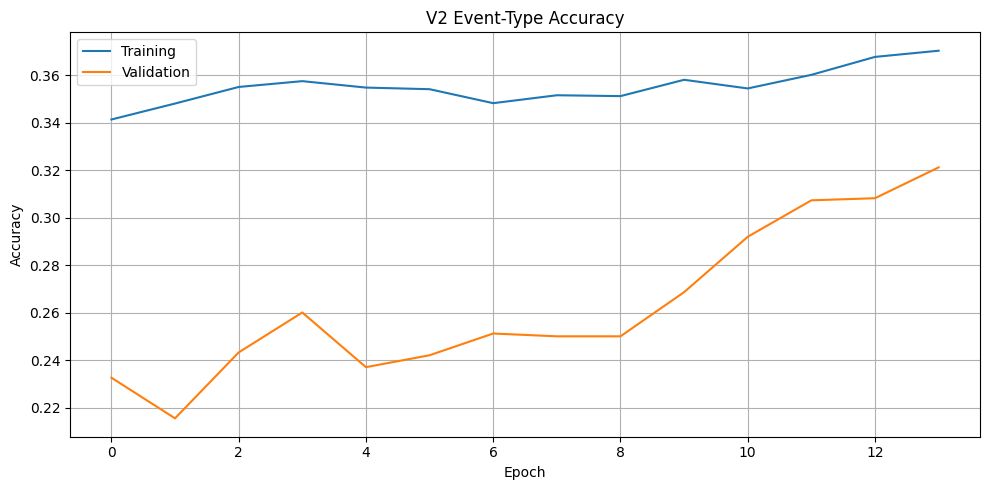

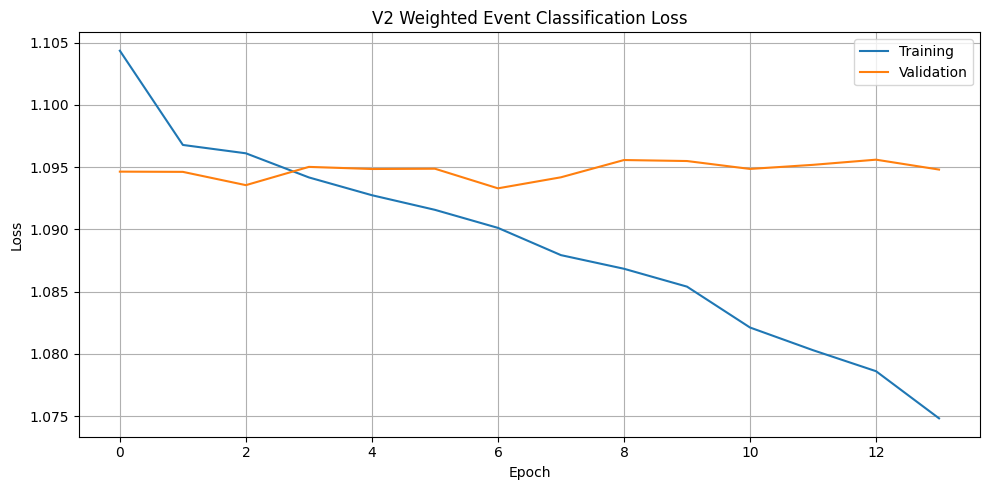

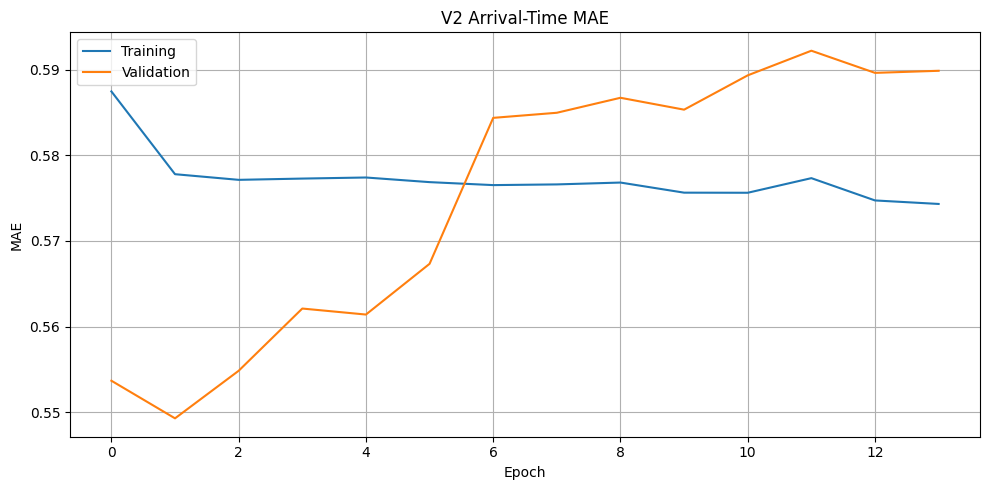

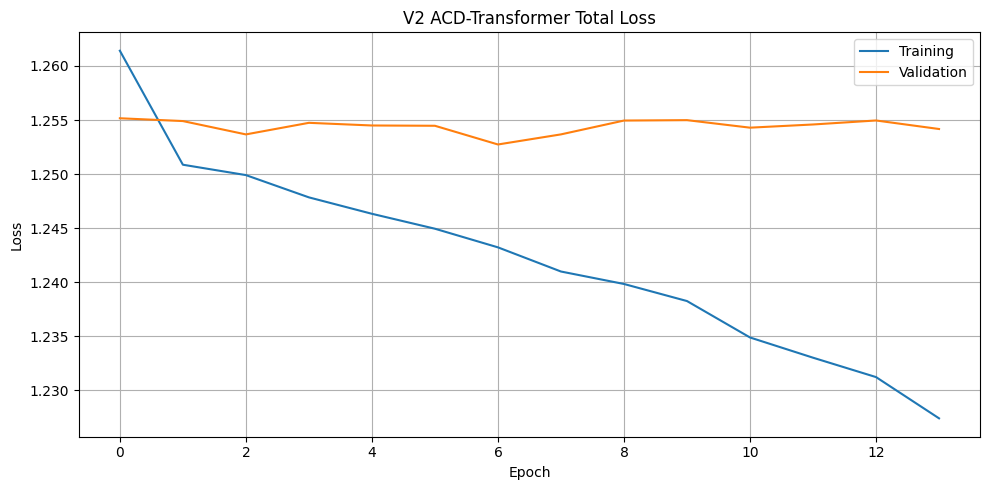

In [ ]:
# ==========================================================
# PART 9
# ROBUST V2 TRAINING
# CUSTOM CLASS-WEIGHTED LOSS
# ==========================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ==========================================================
# 1. CHRONOLOGICAL TRAIN / VALIDATION SPLIT
# ==========================================================

validation_fraction = 0.15

train_end = int(
    len(X_train_sequences)
    * (1 - validation_fraction)
)

X_train_final = X_train_sequences[:train_end]
X_val = X_train_sequences[train_end:]

y_event_train_final = y_event_train_sequences[:train_end]
y_event_val = y_event_train_sequences[train_end:]

y_duration_train_final = y_duration_train_sequences[:train_end]
y_duration_val = y_duration_train_sequences[train_end:]

# ==========================================================
# 2. CLASS WEIGHTS AS TENSOR
# ==========================================================

class_weight_tensor = tf.constant(
    [
        class_weights[0],
        class_weights[1],
        class_weights[2]
    ],
    dtype=tf.float32
)

# ==========================================================
# 3. CUSTOM WEIGHTED EVENT LOSS
# ==========================================================

def weighted_event_loss(
    y_true,
    y_pred
):

    # Convert labels to integer class IDs

    y_true = tf.cast(
        tf.reshape(
            y_true,
            [-1]
        ),
        tf.int32
    )

    # Avoid numerical issues

    y_pred = tf.clip_by_value(
        y_pred,
        1e-7,
        1.0 - 1e-7
    )

    # Convert class IDs to one-hot

    y_true_one_hot = tf.one_hot(
        y_true,
        depth=3
    )

    # Standard categorical cross entropy

    ce = -tf.reduce_sum(
        y_true_one_hot *
        tf.math.log(y_pred),
        axis=-1
    )

    # Select weight corresponding to actual class

    weights = tf.gather(
        class_weight_tensor,
        y_true
    )

    # Weighted loss

    weighted_ce = (
        ce * weights
    )

    return tf.reduce_mean(
        weighted_ce
    )

# ==========================================================
# 4. RECOMPILE MODEL
# ==========================================================

model_v2.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=3e-4
    ),

    loss={

        "Event_Type":
            weighted_event_loss,

        "Event_Duration":
            tf.keras.losses.Huber(
                delta=1.0
            )

    },

    loss_weights={

        "Event_Type": 1.0,

        "Event_Duration": 0.5

    },

    metrics={

        "Event_Type": [
            "accuracy"
        ],

        "Event_Duration": [
            tf.keras.metrics.MeanAbsoluteError(
                name="MAE"
            )
        ]

    }

)

# ==========================================================
# 5. DATA SUMMARY
# ==========================================================

print("=" * 70)
print("V2 TRAINING DATA")
print("=" * 70)

print(
    "Training sequences :",
    X_train_final.shape
)

print(
    "Validation sequences:",
    X_val.shape
)

print(
    "Test sequences      :",
    X_test_sequences.shape
)

print()

print(
    "Class weights:"
)

print(
    "Limit Order   :",
    class_weights[0]
)

print(
    "Market Order  :",
    class_weights[1]
)

print(
    "Cancellation  :",
    class_weights[2]
)

# ==========================================================
# 6. CALLBACKS
# ==========================================================

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=7,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "ACD_Transformer_V2_Best.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

# ==========================================================
# 7. TRAIN MODEL
# ==========================================================

print()
print("=" * 70)
print("TRAINING V2 ACD-TRANSFORMER")
print("=" * 70)

history_v2 = model_v2.fit(

    X_train_final,

    {

        "Event_Type":
            y_event_train_final,

        "Event_Duration":
            y_duration_train_final

    },

    validation_data=(

        X_val,

        {

            "Event_Type":
                y_event_val,

            "Event_Duration":
                y_duration_val

        }

    ),

    epochs=40,

    batch_size=64,

    shuffle=False,

    callbacks=[

        early_stopping,

        reduce_lr,

        checkpoint

    ],

    verbose=1

)

# ==========================================================
# 8. TRAINING SUMMARY
# ==========================================================

print()
print("=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

print(
    "Epochs completed:",
    len(
        history_v2.history["loss"]
    )
)

print(
    "Best validation loss:",
    min(
        history_v2.history["val_loss"]
    )
)

# ==========================================================
# 9. EVENT ACCURACY
# ==========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_v2.history[
        "Event_Type_accuracy"
    ],
    label="Training"
)

plt.plot(
    history_v2.history[
        "val_Event_Type_accuracy"
    ],
    label="Validation"
)

plt.title(
    "V2 Event-Type Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# 10. EVENT LOSS
# ==========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_v2.history[
        "Event_Type_loss"
    ],
    label="Training"
)

plt.plot(
    history_v2.history[
        "val_Event_Type_loss"
    ],
    label="Validation"
)

plt.title(
    "V2 Weighted Event Classification Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# 11. DURATION MAE
# ==========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_v2.history[
        "Event_Duration_MAE"
    ],
    label="Training"
)

plt.plot(
    history_v2.history[
        "val_Event_Duration_MAE"
    ],
    label="Validation"
)

plt.title(
    "V2 Arrival-Time MAE"
)

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# 12. TOTAL LOSS
# ==========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_v2.history["loss"],
    label="Training"
)

plt.plot(
    history_v2.history["val_loss"],
    label="Validation"
)

plt.title(
    "V2 ACD-Transformer Total Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# PART 10
# V2 ACD-TRANSFORMER EVENT EVALUATION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# 1. GENERATE TEST PREDICTIONS
# ==========================================================

print("=" * 70)
print("GENERATING V2 TEST PREDICTIONS")
print("=" * 70)

predictions_v2 = model_v2.predict(
    X_test_sequences,
    verbose=1
)

# ==========================================================
# 2. EXTRACT OUTPUTS
# ==========================================================

event_probabilities_v2 = (
    predictions_v2[0]
)

duration_predictions_v2 = (
    predictions_v2[1]
    .reshape(-1)
)

# ==========================================================
# 3. EVENT PREDICTIONS
# ==========================================================

y_event_pred_v2 = np.argmax(
    event_probabilities_v2,
    axis=1
)

# ==========================================================
# 4. CLASS NAMES
# ==========================================================

class_names = [

    "Limit Order",

    "Market Order",

    "Cancellation"

]

# ==========================================================
# 5. ACCURACY
# ==========================================================

accuracy_v2 = accuracy_score(

    y_event_test_sequences,

    y_event_pred_v2

)

# ==========================================================
# 6. MACRO METRICS
# ==========================================================

precision_macro_v2 = precision_score(

    y_event_test_sequences,

    y_event_pred_v2,

    average="macro",

    zero_division=0

)

recall_macro_v2 = recall_score(

    y_event_test_sequences,

    y_event_pred_v2,

    average="macro",

    zero_division=0

)

f1_macro_v2 = f1_score(

    y_event_test_sequences,

    y_event_pred_v2,

    average="macro",

    zero_division=0

)

# ==========================================================
# 7. WEIGHTED METRICS
# ==========================================================

precision_weighted_v2 = precision_score(

    y_event_test_sequences,

    y_event_pred_v2,

    average="weighted",

    zero_division=0

)

recall_weighted_v2 = recall_score(

    y_event_test_sequences,

    y_event_pred_v2,

    average="weighted",

    zero_division=0

)

f1_weighted_v2 = f1_score(

    y_event_test_sequences,

    y_event_pred_v2,

    average="weighted",

    zero_division=0

)

# ==========================================================
# 8. FINAL CLASSIFICATION RESULTS
# ==========================================================

print()
print("=" * 70)
print("V2 EVENT PREDICTION RESULTS")
print("=" * 70)

print(
    f"Accuracy          : {accuracy_v2:.4f}"
)

print(
    f"Macro Precision    : {precision_macro_v2:.4f}"
)

print(
    f"Macro Recall       : {recall_macro_v2:.4f}"
)

print(
    f"Macro F1           : {f1_macro_v2:.4f}"
)

print(
    f"Weighted Precision : {precision_weighted_v2:.4f}"
)

print(
    f"Weighted Recall    : {recall_weighted_v2:.4f}"
)

print(
    f"Weighted F1        : {f1_weighted_v2:.4f}"
)

# ==========================================================
# 9. CLASSIFICATION REPORT
# ==========================================================

print()
print("=" * 70)
print("V2 CLASSIFICATION REPORT")
print("=" * 70)

print(

    classification_report(

        y_event_test_sequences,

        y_event_pred_v2,

        labels=[0, 1, 2],

        target_names=class_names,

        zero_division=0

    )

)

# ==========================================================
# 10. CONFUSION MATRIX
# ==========================================================

cm_v2 = confusion_matrix(

    y_event_test_sequences,

    y_event_pred_v2,

    labels=[0, 1, 2]

)

print()
print("=" * 70)
print("V2 CONFUSION MATRIX")
print("=" * 70)

print(cm_v2)

# ==========================================================
# 11. CONFUSION MATRIX PLOT
# ==========================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    cm_v2,
    interpolation="nearest"
)

plt.title(
    "V2 ACD-Transformer Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(3),
    class_names,
    rotation=20
)

plt.yticks(
    range(3),
    class_names
)

plt.xlabel(
    "Predicted Event"
)

plt.ylabel(
    "Actual Event"
)

# Add numbers

for i in range(3):

    for j in range(3):

        plt.text(

            j,
            i,

            str(cm_v2[i, j]),

            ha="center",

            va="center"

        )

plt.tight_layout()

plt.show()

# ==========================================================
# 12. ACTUAL DISTRIBUTION
# ==========================================================

actual_distribution_v2 = (

    pd.Series(
        y_event_test_sequences
    )

    .map({
        0: "Limit Order",
        1: "Market Order",
        2: "Cancellation"
    })

    .value_counts()

)

# ==========================================================
# 13. PREDICTED DISTRIBUTION
# ==========================================================

predicted_distribution_v2 = (

    pd.Series(
        y_event_pred_v2
    )

    .map({
        0: "Limit Order",
        1: "Market Order",
        2: "Cancellation"
    })

    .value_counts()

)

distribution_v2 = pd.DataFrame({

    "Actual":
        actual_distribution_v2,

    "Predicted":
        predicted_distribution_v2

}).fillna(0)

print()
print("=" * 70)
print("ACTUAL vs PREDICTED DISTRIBUTION")
print("=" * 70)

print(
    distribution_v2
)

# ==========================================================
# 14. PREDICTION CONFIDENCE
# ==========================================================

confidence_v2 = np.max(

    event_probabilities_v2,

    axis=1

)

print()
print("=" * 70)
print("PREDICTION CONFIDENCE")
print("=" * 70)

print(
    pd.Series(
        confidence_v2
    ).describe()
)

# ==========================================================
# 15. HIGH-CONFIDENCE PREDICTIONS
# ==========================================================

for threshold in [0.50, 0.70, 0.90]:

    percentage = (

        confidence_v2 >= threshold

    ).mean() * 100

    print(

        f"Confidence >= "
        f"{threshold:.0%}: "
        f"{percentage:.2f}%"

    )

# ==========================================================
# 16. SAVE RESULTS
# ==========================================================

v2_results = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Macro Precision",

        "Macro Recall",

        "Macro F1",

        "Weighted Precision",

        "Weighted Recall",

        "Weighted F1"

    ],

    "Value": [

        accuracy_v2,

        precision_macro_v2,

        recall_macro_v2,

        f1_macro_v2,

        precision_weighted_v2,

        recall_weighted_v2,

        f1_weighted_v2

    ]

})

v2_results.to_csv(

    "ACD_Transformer_V2_Event_Results.csv",

    index=False

)

print()
print("=" * 70)
print("EVENT EVALUATION COMPLETED")
print("=" * 70)

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
V2 ARRIVAL-TIME FORECASTING RESULTS
MAE                 : 0.034401 seconds
RMSE                : 0.066996 seconds
R²                  : -0.035543
Pearson Correlation : 0.014849
Spearman Correlation: 0.024108

DURATION SUMMARY
Actual Mean Duration    : 0.125936 sec
Predicted Mean Duration : 0.113543 sec
Actual Median Duration    : 0.100000 sec
Predicted Median Duration : 0.113411 sec


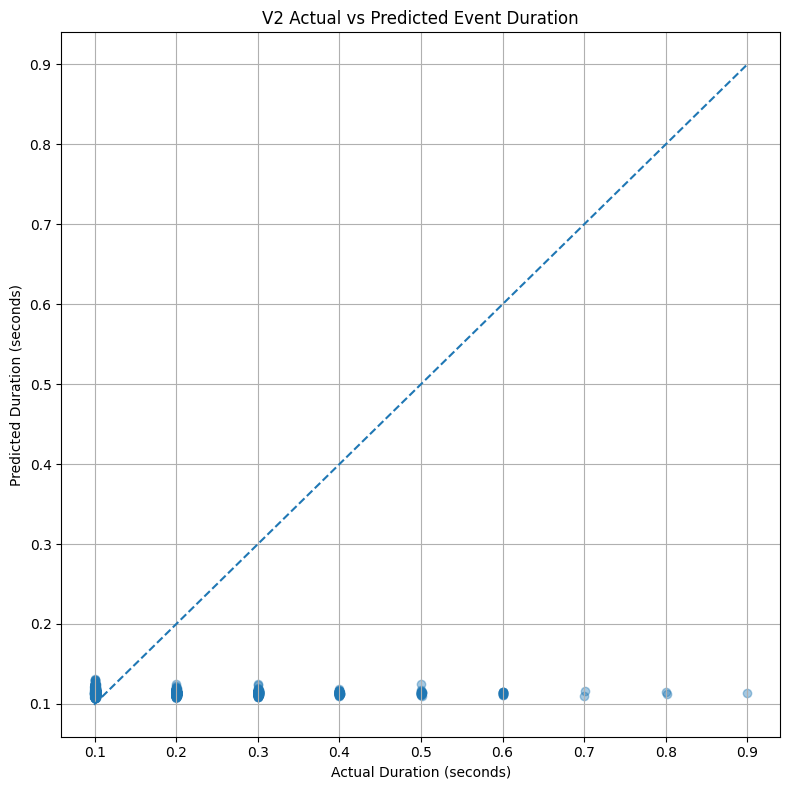

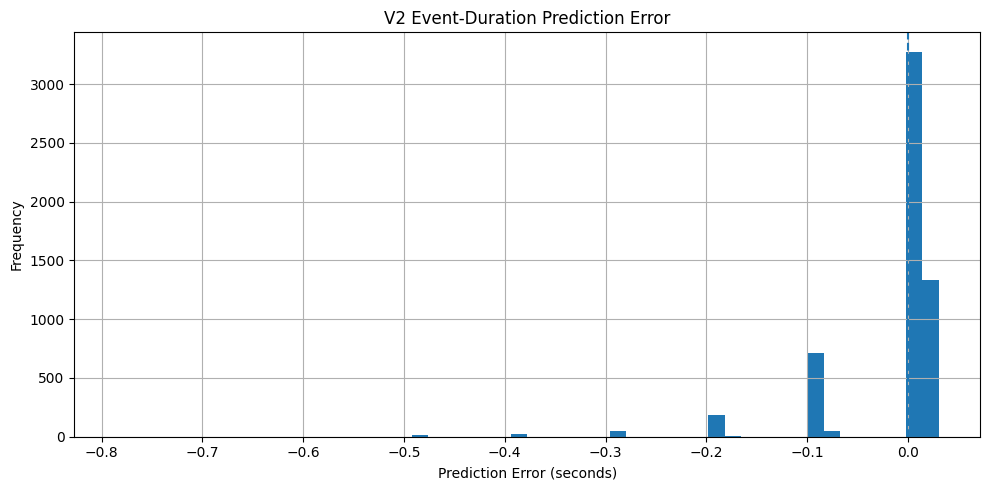


DURATION ERROR DISTRIBUTION
count    5653.000000
mean       -0.012393
std         0.065846
min        -0.786160
25%         0.010837
50%         0.012748
75%         0.014329
max         0.030758
dtype: float64

ARRIVAL-TIME EVALUATION COMPLETED


In [30]:
# ==========================================================
# PART 11
# V2 ARRIVAL-TIME FORECASTING EVALUATION
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================================
# 1. GENERATE TEST PREDICTIONS
# ==========================================================

predictions_v2 = model_v2.predict(
    X_test_sequences,
    verbose=1
)

# ==========================================================
# 2. EXTRACT DURATION PREDICTIONS
# ==========================================================

duration_pred_scaled_v2 = (
    predictions_v2[1]
    .reshape(-1, 1)
)

# ==========================================================
# 3. REVERSE STANDARDIZATION
# ==========================================================

duration_pred_log_v2 = (
    duration_scaler
    .inverse_transform(
        duration_pred_scaled_v2
    )
    .flatten()
)

# ==========================================================
# 4. REVERSE LOG TRANSFORMATION
# ==========================================================

duration_pred_v2 = np.expm1(
    duration_pred_log_v2
)

# ==========================================================
# 5. ACTUAL DURATIONS
# ==========================================================

duration_actual_log_v2 = (
    duration_scaler
    .inverse_transform(
        y_duration_test_sequences
        .reshape(-1, 1)
    )
    .flatten()
)

duration_actual_v2 = np.expm1(
    duration_actual_log_v2
)

# ==========================================================
# 6. REMOVE INVALID VALUES
# ==========================================================

valid = (

    np.isfinite(
        duration_actual_v2
    )

    &

    np.isfinite(
        duration_pred_v2
    )

)

duration_actual_v2 = (
    duration_actual_v2[valid]
)

duration_pred_v2 = (
    duration_pred_v2[valid]
)

# Duration cannot be negative

duration_pred_v2 = np.maximum(
    duration_pred_v2,
    0
)

# ==========================================================
# 7. ERROR METRICS
# ==========================================================

mae_v2 = mean_absolute_error(

    duration_actual_v2,

    duration_pred_v2

)

rmse_v2 = np.sqrt(
    mean_squared_error(

        duration_actual_v2,

        duration_pred_v2

    )
)

r2_v2 = r2_score(

    duration_actual_v2,

    duration_pred_v2

)

# ==========================================================
# 8. CORRELATION
# ==========================================================

if len(duration_actual_v2) > 1:

    pearson_v2 = np.corrcoef(

        duration_actual_v2,

        duration_pred_v2

    )[0, 1]

else:

    pearson_v2 = np.nan

actual_rank_v2 = (
    pd.Series(
        duration_actual_v2
    ).rank()
)

pred_rank_v2 = (
    pd.Series(
        duration_pred_v2
    ).rank()
)

spearman_v2 = np.corrcoef(

    actual_rank_v2,

    pred_rank_v2

)[0, 1]

# ==========================================================
# 9. PRINT RESULTS
# ==========================================================

print("=" * 70)
print("V2 ARRIVAL-TIME FORECASTING RESULTS")
print("=" * 70)

print(
    f"MAE                 : "
    f"{mae_v2:.6f} seconds"
)

print(
    f"RMSE                : "
    f"{rmse_v2:.6f} seconds"
)

print(
    f"R²                  : "
    f"{r2_v2:.6f}"
)

print(
    f"Pearson Correlation : "
    f"{pearson_v2:.6f}"
)

print(
    f"Spearman Correlation: "
    f"{spearman_v2:.6f}"
)

# ==========================================================
# 10. DURATION SUMMARY
# ==========================================================

print()
print("=" * 70)
print("DURATION SUMMARY")
print("=" * 70)

print(
    f"Actual Mean Duration    : "
    f"{duration_actual_v2.mean():.6f} sec"
)

print(
    f"Predicted Mean Duration : "
    f"{duration_pred_v2.mean():.6f} sec"
)

print(
    f"Actual Median Duration    : "
    f"{np.median(duration_actual_v2):.6f} sec"
)

print(
    f"Predicted Median Duration : "
    f"{np.median(duration_pred_v2):.6f} sec"
)

# ==========================================================
# 11. ACTUAL vs PREDICTED
# ==========================================================

plt.figure(figsize=(8, 8))

plt.scatter(

    duration_actual_v2,

    duration_pred_v2,

    alpha=0.4

)

min_value = min(

    duration_actual_v2.min(),

    duration_pred_v2.min()

)

max_value = max(

    duration_actual_v2.max(),

    duration_pred_v2.max()

)

plt.plot(

    [min_value, max_value],

    [min_value, max_value],

    linestyle="--"

)

plt.title(
    "V2 Actual vs Predicted Event Duration"
)

plt.xlabel(
    "Actual Duration (seconds)"
)

plt.ylabel(
    "Predicted Duration (seconds)"
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# 12. PREDICTION ERROR
# ==========================================================

duration_error_v2 = (

    duration_pred_v2

    -

    duration_actual_v2

)

plt.figure(figsize=(10, 5))

plt.hist(

    duration_error_v2,

    bins=50

)

plt.axvline(

    0,

    linestyle="--"

)

plt.title(
    "V2 Event-Duration Prediction Error"
)

plt.xlabel(
    "Prediction Error (seconds)"
)

plt.ylabel(
    "Frequency"
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# 13. ERROR DISTRIBUTION
# ==========================================================

print()
print("=" * 70)
print("DURATION ERROR DISTRIBUTION")
print("=" * 70)

print(
    pd.Series(
        duration_error_v2
    ).describe()
)

# ==========================================================
# 14. SAVE RESULTS
# ==========================================================

arrival_results_v2 = pd.DataFrame({

    "Metric": [

        "MAE",

        "RMSE",

        "R2",

        "Pearson",

        "Spearman",

        "Actual Mean Duration",

        "Predicted Mean Duration",

        "Actual Median Duration",

        "Predicted Median Duration"

    ],

    "Value": [

        mae_v2,

        rmse_v2,

        r2_v2,

        pearson_v2,

        spearman_v2,

        duration_actual_v2.mean(),

        duration_pred_v2.mean(),

        np.median(
            duration_actual_v2
        ),

        np.median(
            duration_pred_v2
        )

    ]

})

arrival_results_v2.to_csv(

    "ACD_Transformer_V2_Arrival_Time_Results.csv",

    index=False

)

print()
print("=" * 70)
print("ARRIVAL-TIME EVALUATION COMPLETED")
print("=" * 70)

In [31]:
# ==========================================================
# PART 12
# FINAL V2 ACD-TRANSFORMER RESEARCH SUMMARY
# ==========================================================

import numpy as np
import pandas as pd

# ==========================================================
# 1. FINAL EVENT METRICS
# ==========================================================

final_event_metrics = {

    "Accuracy":
        accuracy_v2,

    "Macro Precision":
        precision_macro_v2,

    "Macro Recall":
        recall_macro_v2,

    "Macro F1":
        f1_macro_v2,

    "Weighted Precision":
        precision_weighted_v2,

    "Weighted Recall":
        recall_weighted_v2,

    "Weighted F1":
        f1_weighted_v2

}

# ==========================================================
# 2. FINAL ARRIVAL-TIME METRICS
# ==========================================================

final_duration_metrics = {

    "Arrival MAE":
        mae_v2,

    "Arrival RMSE":
        rmse_v2,

    "Arrival R2":
        r2_v2,

    "Pearson":
        pearson_v2,

    "Spearman":
        spearman_v2

}

# ==========================================================
# 3. COMBINED RESULTS
# ==========================================================

final_results_v2 = pd.DataFrame({

    "Category": [

        "Event Classification",
        "Event Classification",
        "Event Classification",
        "Event Classification",
        "Event Classification",
        "Event Classification",
        "Event Classification",

        "Arrival-Time Forecasting",
        "Arrival-Time Forecasting",
        "Arrival-Time Forecasting",
        "Arrival-Time Forecasting",
        "Arrival-Time Forecasting"

    ],

    "Metric": [

        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",

        "MAE",
        "RMSE",
        "R²",
        "Pearson",
        "Spearman"

    ],

    "Value": [

        accuracy_v2,
        precision_macro_v2,
        recall_macro_v2,
        f1_macro_v2,
        precision_weighted_v2,
        recall_weighted_v2,
        f1_weighted_v2,

        mae_v2,
        rmse_v2,
        r2_v2,
        pearson_v2,
        spearman_v2

    ]

})

print("=" * 70)
print("FINAL V2 ACD-TRANSFORMER RESULTS")
print("=" * 70)

print(
    final_results_v2.to_string(
        index=False
    )
)

# ==========================================================
# 4. EVENT DISTRIBUTION
# ==========================================================

print()
print("=" * 70)
print("EVENT DISTRIBUTION")
print("=" * 70)

event_distribution_v2 = (

    pd.Series(
        y_event_test_sequences
    )

    .map({
        0: "Limit Order",
        1: "Market Order",
        2: "Cancellation"
    })

    .value_counts()

)

event_distribution_v2 = pd.DataFrame({

    "Count":
        event_distribution_v2,

    "Percentage":
        event_distribution_v2
        .div(
            event_distribution_v2.sum()
        )
        .mul(100)

})

event_distribution_v2["Percentage"] = (
    event_distribution_v2["Percentage"]
    .round(2)
)

print(
    event_distribution_v2
)

# ==========================================================
# 5. PREDICTION DISTRIBUTION
# ==========================================================

print()
print("=" * 70)
print("PREDICTED EVENT DISTRIBUTION")
print("=" * 70)

prediction_distribution_v2 = (

    pd.Series(
        y_event_pred_v2
    )

    .map({
        0: "Limit Order",
        1: "Market Order",
        2: "Cancellation"
    })

    .value_counts()

)

prediction_distribution_v2 = pd.DataFrame({

    "Count":
        prediction_distribution_v2,

    "Percentage":
        prediction_distribution_v2
        .div(
            prediction_distribution_v2.sum()
        )
        .mul(100)

})

prediction_distribution_v2["Percentage"] = (
    prediction_distribution_v2["Percentage"]
    .round(2)
)

print(
    prediction_distribution_v2
)

# ==========================================================
# 6. CONFUSION MATRIX
# ==========================================================

print()
print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm_v2)

# ==========================================================
# 7. DURATION STATISTICS
# ==========================================================

duration_statistics_v2 = pd.DataFrame({

    "Metric": [

        "Actual Mean",
        "Predicted Mean",

        "Actual Median",
        "Predicted Median",

        "Actual Std",
        "Predicted Std",

        "MAE",
        "RMSE",
        "R²",

        "Pearson",
        "Spearman"

    ],

    "Value": [

        duration_actual_v2.mean(),
        duration_pred_v2.mean(),

        np.median(
            duration_actual_v2
        ),

        np.median(
            duration_pred_v2
        ),

        duration_actual_v2.std(),
        duration_pred_v2.std(),

        mae_v2,
        rmse_v2,
        r2_v2,

        pearson_v2,
        spearman_v2

    ]

})

print()
print("=" * 70)
print("ARRIVAL-TIME STATISTICS")
print("=" * 70)

print(
    duration_statistics_v2.to_string(
        index=False
    )
)

# ==========================================================
# 8. MODEL CONFIGURATION
# ==========================================================

model_configuration = pd.DataFrame({

    "Parameter": [

        "Input Features",
        "Sequence Length",
        "Transformer Dimension",
        "Attention Heads",
        "Feed Forward Dimension",
        "Transformer Blocks",
        "Batch Size",
        "Maximum Epochs",
        "Optimizer",
        "Learning Rate",
        "Event Loss",
        "Duration Loss"

    ],

    "Value": [

        X_train_sequences.shape[2],

        X_train_sequences.shape[1],

        128,

        4,

        256,

        2,

        64,

        40,

        "Adam",

        3e-4,

        "Weighted Cross Entropy",

        "Huber"

    ]

})

print()
print("=" * 70)
print("MODEL CONFIGURATION")
print("=" * 70)

print(
    model_configuration.to_string(
        index=False
    )
)

# ==========================================================
# 9. SAVE COMPLETE RESULTS
# ==========================================================

final_results_v2.to_csv(
    "ACD_Transformer_V2_Final_Results.csv",
    index=False
)

event_distribution_v2.to_csv(
    "ACD_Transformer_V2_Event_Distribution.csv"
)

duration_statistics_v2.to_csv(
    "ACD_Transformer_V2_Duration_Statistics.csv",
    index=False
)

model_configuration.to_csv(
    "ACD_Transformer_V2_Model_Configuration.csv",
    index=False
)

# ==========================================================
# 10. FINAL RESEARCH STATEMENT
# ==========================================================

print()
print("=" * 70)
print("RESEARCH SUMMARY")
print("=" * 70)

print("""
ACD-Transformer V2 integrates:

1. Level-2 order-book structure
2. Trade-flow information
3. Order-flow imbalance
4. Queue and liquidity measures
5. Inter-event duration dynamics
6. Event-intensity features
7. Transformer-based temporal representation

The model jointly addresses two tasks:

WHAT:
Prediction of the next LOB event type.

WHEN:
Prediction of the next-event arrival time.

The event classes are reconstructed at the
LOB snapshot-interval level using both depth
and trade information.

These labels should therefore be described as
trade-aware LOB event labels rather than
exchange-native order-event labels.
""")

print("=" * 70)
print("V2 ANALYSIS COMPLETED")
print("=" * 70)

FINAL V2 ACD-TRANSFORMER RESULTS
                Category             Metric     Value
    Event Classification           Accuracy  0.260216
    Event Classification    Macro Precision  0.345061
    Event Classification       Macro Recall  0.340227
    Event Classification           Macro F1  0.219420
    Event Classification Weighted Precision  0.384586
    Event Classification    Weighted Recall  0.260216
    Event Classification        Weighted F1  0.207413
Arrival-Time Forecasting                MAE  0.034401
Arrival-Time Forecasting               RMSE  0.066996
Arrival-Time Forecasting                 R² -0.035543
Arrival-Time Forecasting            Pearson  0.014849
Arrival-Time Forecasting           Spearman  0.024108

EVENT DISTRIBUTION
              Count  Percentage
Cancellation   2701       47.78
Market Order   1744       30.85
Limit Order    1208       21.37

PREDICTED EVENT DISTRIBUTION
              Count  Percentage
Limit Order    4592       81.23
Cancellation    740    